**Python implementation of Van der pol oscillator, base paper "WyNDA"**

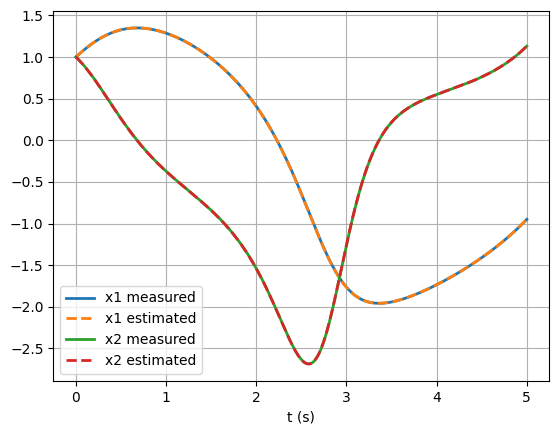

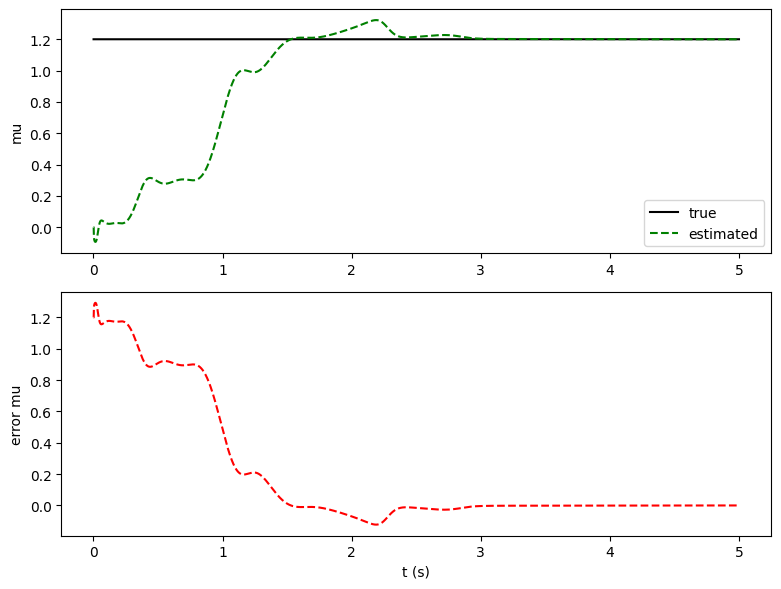

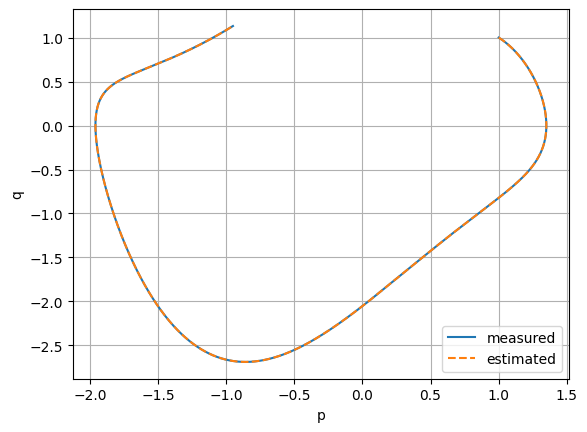

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# time horizon
tf = 5
dt = 0.001
t = np.arange(dt, tf + dt, dt)

# dimensions
n = 2
r = 18

# noise
R = 0

# initial states
x = np.array([1.0, 1.0])
xbar = x.copy()
y = x.copy()

thetabar = np.zeros(r)

# true parameter
mu = 1.2


# storage
xArray = []
xbarArray = []
yArray = []
thetabarArray = []

# estimator initialization
lambdav = 0.995
lambdat = 0.999

Rx = np.eye(n)
Rt = np.eye(n)

Px = 0.1 * np.eye(n)
Pt = 0.1 * np.eye(r)

Gamma = np.zeros((n, r))

# simualtions
for i in range(int(tf/dt)):

    xArray.append(x.copy())
    xbarArray.append(xbar.copy())
    yArray.append(y.copy())
    thetabarArray.append(thetabar.copy())

    # Van der Pol dynamics
    dx = np.array([
        x[1],
        mu*(1 - x[0]**2)*x[1] - x[0]
    ])

    x = x + dt * dx
    y = x + dt*(R**2)*np.random.randn(n)

    # library matrix phi
    Phi = np.zeros((2,18))

    Phi[0,0:9] = [
        y[0], y[1],
        y[0]**2, y[1]**2,
        y[0]*y[1],
        y[0]**3, y[1]**3,
        y[0]**2*y[1],
        y[0]*y[1]**2
    ]

    Phi[1,9:18] = Phi[0,0:9]


    # adaptive observer
    Kx = Px @ np.linalg.inv(Px + Rx)
    Kt = Pt @ Gamma.T @ np.linalg.inv(Gamma @ Pt @ Gamma.T + Rt)

    Gamma = (np.eye(n) - Kx) @ Gamma

    xbar = xbar + (Kx + Gamma @ Kt) @ (y - xbar)
    thetabar = thetabar - Kt @ (y - xbar)

    xbar = xbar + Phi @ thetabar

    Px = (1/lambdav) * (np.eye(n) - Kx) @ Px
    Pt = (1/lambdat) * (np.eye(r) - Kt @ Gamma) @ Pt

    Gamma = Gamma - Phi


# convert arrays
xArray = np.array(xArray).T
xbarArray = np.array(xbarArray).T
yArray = np.array(yArray).T
thetabarArray = np.array(thetabarArray).T


# States vs Time
plt.figure()

plt.plot(t, yArray[0], linewidth=2)
plt.plot(t, xbarArray[0], '--', linewidth=2)

plt.plot(t, yArray[1], linewidth=2)
plt.plot(t, xbarArray[1], '--', linewidth=2)

plt.grid(True)
plt.xlabel("t (s)")
plt.legend(["x1 measured","x1 estimated","x2 measured","x2 estimated"])

plt.show()

# Parameter estimation
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
plt.plot(t, mu*np.ones_like(t),'k')
plt.plot(t, thetabarArray[10]/dt,'g--')
plt.ylabel("mu")
plt.legend(["true","estimated"])

plt.subplot(2,1,2)
plt.plot(t, mu - thetabarArray[10]/dt,'r--')
plt.ylabel("error mu")
plt.xlabel("t (s)")

plt.tight_layout()
plt.show()


# Phase portrait
plt.figure()

plt.plot(yArray[0], yArray[1])
plt.plot(xbarArray[0], xbarArray[1], '--')

plt.xlabel("p")
plt.ylabel("q")
plt.legend(["measured","estimated"])
plt.grid(True)

plt.show()
